# Counting: Sample the Field at Random Positions

This notebook shows how PyHermes turns a saved `ConvolsData` field into a one-point sampling dataset. The main idea is simple: optionally smooth the field, evaluate it at many random positions, and study the resulting distribution.

The interpretation of the sampled values follows the upstream `ConvolsData`: a unit-value field samples a catalogue-normalized tracer density, while a mass-valued field carries the catalogue-weighted mean mass amplitude.

## What this notebook emphasizes

- the standard task interfaces for `Counting`
- how `ConvolsData` and `WindowFunc` are passed into the task
- how sampled values can be used to inspect the PDF of a smoothed tracer-density or mass-valued field


In [1]:
from pyhermes.theory.counting import Counting
from pyhermes.param.parambase import read_param
from pyhermes.utils.sampling import random_box_positions
from pyhermes.io import WindowFunc, ConvolsData, CountingData
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

figs_dir = Path("figs_new")
figs_dir.mkdir(exist_ok=True)


Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Standard `Counting` workflows

All workflows below do the same conceptual job: draw random points in the box and evaluate either the unfiltered field or a smoothed version of it at those positions.


### Minimal YAML Shapes

`Counting` reads a saved `ConvolsData` field, optionally applies an ordinary smoothing window, and samples the result at random positions:

```yaml
Counting:
   convols_data: "./output_new/quijote8000_snap004_sfc.pkl"
   random_count: 10000000
   window:
      type: "sphere"
      len_args:
         R: 20
   threads: 8
   fout_path: "./output_new/quijote8000_snap004_counting_sph20.pkl"
```

Omit `window` if you want to sample the unfiltered field. When `window` is present, it is a normal smoothing `WindowFunc`, not a pair window.

### Command-line entry point

Use the standard driver when you want the cleanest path from config file to saved output.


In [2]:
! python ./scripts/run_counting.py ./configs/param_counting.yaml

17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data' from 'empty' to './output_new/quijote8000_snap004_sfc.pkl'
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.random_count' from '1000000' to '10000000'
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
17:23:54 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.threads' from '1' to '8'
17:23:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output_new/q

### Config-driven Python API

This keeps the YAML config in control while making the resulting `CountingData` object immediately available in the notebook.


In [3]:
counting_params = read_param('./configs/param_counting.yaml')
task = Counting(param_task=counting_params)
task.run(overwrite=True)

17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data' from 'empty' to './output_new/quijote8000_snap004_sfc.pkl'
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.random_count' from '1000000' to '10000000'
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
17:23:57 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.threads' from '1' to '8'
17:23:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output_new/q

### Task object overrides

This version creates the task first and then adjusts a few attributes in Python. It is useful when you want to change the sample count, smoothing window, or threading without editing the config file.

Here the input is `quijote8000_snap004_sfc_massweight.pkl`, so `counting_massw.nx` samples a smoothed mass-valued field on the same catalogue measure rather than the unit-value tracer field.


In [4]:
task = Counting()
task.threads = 8
task.random_count = 1000000
task.convols_data = './output_new/quijote8000_snap004_sfc_massweight.pkl'
task.window = {"type": "sphere", "len_args": {"R": 20}}
counting_massw = task.run(save_result=False)

17:24:01 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

17:24:01 - INFO - pyhermes.pipeline.pipeline:Counting - Counting runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:24:01 - INFO - pyhermes.pipeline.pipeline:Counting - Preparing Counting input field ...
17:24:01 - INFO - pyhermes.pipeline.pipeline:Counting - random_count=1000000, seed=42, threads=8
17:24:01 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output_new/quijote8000_snap004_sfc_massweight.pkl <---
17:24:01 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -1.1e+15, Max = 4.779e+15, Mean = 1.171e+12, Sum = 1.965e+19
17:24:01 - INFO - pyhermes.pipeline.pipeline:Counting - Counting field ready | source=path=./output_new/quijote8000_snap004_sfc_massweight.pkl | window=provided window dict | applying window type=sphere args={'R': 20}
17:24:01 - INFO - pyhermes.pipeline.pipeline:Counting - Start Counting ..

### Manual object preparation

Here the upstream `ConvolsData` object and the smoothing window are created explicitly before they are passed into `Counting`. This makes the data flow fully visible.


In [5]:
D = ConvolsData(data_path='./output_new/quijote8000_snap004_rsd_sfc.pkl', threads=8)
win_params = {"type": "sphere", "len_args": {"R": 20}}
filter_sph20 = WindowFunc(win_params, D.convols_info, threads=8)

task = Counting()
task.threads = 8
task.N_randoms = 1000000
task.convols_data = D.copy()
task.window = filter_sph20
counting_rsd = task.run(save_result=False)

17:24:01 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output_new/quijote8000_snap004_rsd_sfc.pkl <---
17:24:02 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -1.433, Max = 7.164, Mean = 0.02424, Sum = 4.067e+05
17:24:02 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - Counting runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - Preparing Counting input field ...
17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - random_count=1000000, seed=42, threads=8
17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - Counting field ready | source=provided convols_data | window=provided WindowFunc instance
17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - Start Counting ... 
17:24:02 - INFO - pyhermes.pipeline.pipeline:Counting - Gathering data from all rank

## 2. Inspect the saved counting result

The saved `CountingData` object stores the sampled values. A histogram of `counting.nx` gives a quick view of the one-point distribution produced by the chosen smoothing scale.

The plot below normalizes each sampled field by its own mean. The unit-value real-space and redshift-space fields are shown as $D(x) / \bar D - 1$, while the mass-valued run is shown after division by its catalogue-weighted mean mark. This keeps the contrast notation consistent while making clear which physical field was sampled.


17:24:02 - INFO - pyhermes.io.base:CountingData - Reading Counting data from ---> ./output_new/quijote8000_snap004_counting_sph20.pkl <---
17:24:02 - INFO - pyhermes.io.base:CountingData - nx: Shape(10000000,), Min = -0.0001257, Max = 0.002199, Mean = 0.0004069


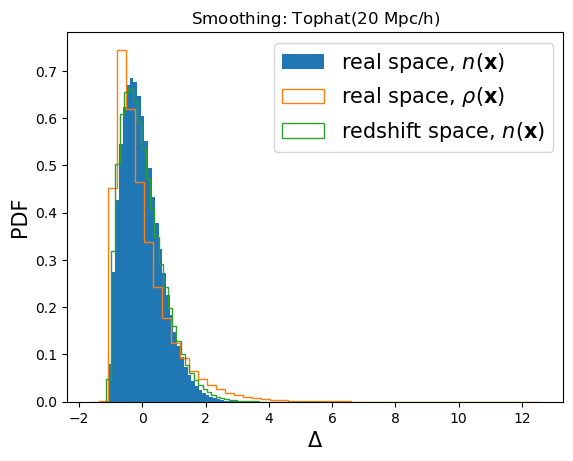

In [6]:
# read counting
counting_real = CountingData(data_path="./output_new/quijote8000_snap004_counting_sph20.pkl")

plt.hist(counting_real.nx/counting_real.nx.mean()-1, bins=50, density=True, label=r'real space, $n(\mathbf{x})$')
plt.hist(counting_massw.nx/counting_massw.nx.mean()-1, bins=50, density=True, histtype="step", label=r'real space, $\rho(\mathbf{x})$')
plt.hist(counting_rsd.nx/counting_rsd.nx.mean()-1, bins=50, density=True, histtype="step", label=r'redshift space, $n(\mathbf{x})$')
plt.legend(fontsize=15)
plt.title(r"Smoothing: Tophat(20 $\rm{Mpc}/h$)")
plt.xlabel(r'$\Delta$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.savefig(figs_dir / "counting_density_mass_rsd_pdf.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Low-level view: sample the smoothed field directly

The cells below expose the same logic that the high-level `Counting` task uses internally. We first draw random positions in the simulation box, convolve the saved `ConvolsData` field with a chosen smoothing window, and evaluate the smoothed number density at those positions with `n_at_pos`.

For the unit-value halo field, the sampled values form a catalogue-normalized density. We convert them to density contrast using its known global mean, not the mean of the random sample,

$$
\delta_n({\bf x}) = \frac{D({\bf x})}{\rho} - 1,\qquad \rho = \frac{1}{V}.
$$

Equivalently, we can first build the full density-contrast field

$$
\delta({\bf x}) = \frac{D({\bf x})}{\langle D\rangle_{\rm grid}} - 1,
$$

then convolve and sample this derived field. In code this requires `physical=False` in `n_at_pos`, because the field is already dimensionless and should not receive the physical-coordinate density conversion used for a catalogue density field. The two routes represent the same continuum operation; any remaining differences are numerical interpolation or finite-grid effects.


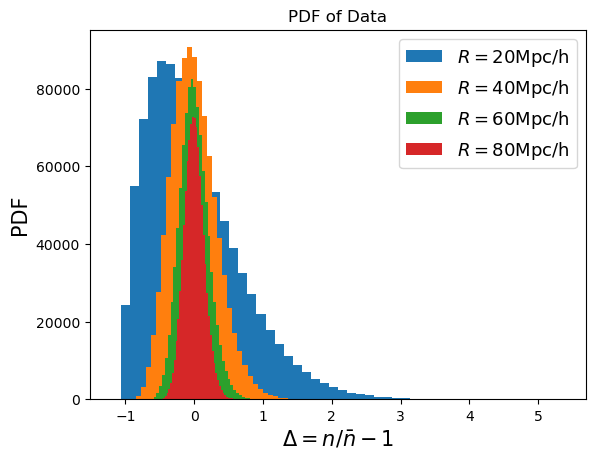

In [7]:
rand = random_box_positions(10**6, D.box_size)
win_params = dict(type="sphere", len_args={})
for smooth_radius in [20, 40, 60, 80]:
    win_params["len_args"]["R"] = smooth_radius
    filter = WindowFunc(win_params, D.convols_info, threads=8)
    # n = D.n_at_pos(rand, filter=filter)
    n = (D @ filter).n_at_pos(rand)
    n_bar = 1.0 / D.box_size**3
    delta_n = n / n_bar - 1.0
    plt.hist(delta_n, bins=50, density=False, label=rf'$R={smooth_radius}$Mpc/h')

plt.title('PDF of Data')
plt.xlabel(r'$\Delta=n/{\bar n}-1$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.legend(fontsize=13)
plt.savefig(figs_dir / "counting_smoothing_radius_pdf.png", dpi=200, bbox_inches="tight")
plt.show()

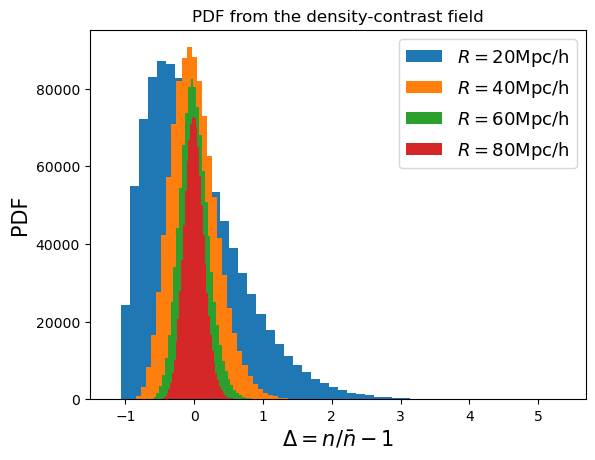

In [8]:
delta = D / D.epsilon.mean() - 1.0
for smooth_radius in [20, 40, 60, 80]:
    win_params["len_args"]["R"] = smooth_radius
    filter = WindowFunc(win_params, D.convols_info, threads=8)
    delta_n = (delta @ filter).n_at_pos(rand, physical=False)
    plt.hist(delta_n, bins=50, density=False, label=rf'$R={smooth_radius}$Mpc/h')

plt.title(r'PDF from the density-contrast field')
plt.xlabel(r'$\Delta=n/{\bar n}-1$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.legend(fontsize=13)
plt.savefig(figs_dir / "counting_delta_field_smoothing_radius_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. One-field second moment: $\sigma_W(R)$

Once the density-contrast field is available, its smoothed one-point RMS fluctuation can be computed directly with PyHermes field algebra:

$$
\delta_W({\bf x};R) = \delta \circ W_R,
\qquad
\sigma_W(R) = \left\langle \delta_W^2({\bf x};R) \right\rangle^{1/2}.
$$

The helper `compute_sigma_w` below wraps this operation: build the requested window, convolve the density-contrast field, and return the RMS of the smoothed field. The first figure compares two low-pass smoothing families, spherical top-hat and Gaussian. The vertical dashed line marks $R=8\,h^{-1}{\rm Mpc}$. In the standard cosmological convention, $\sigma_8$ refers to the spherical top-hat RMS at this radius, so the marker is placed on the top-hat curve and its value is computed directly at $R=8$ rather than interpolated from the plotted sampling points. Here the plotted value is the corresponding RMS of the current halo density-contrast field, not the linear-theory matter $\sigma_8$ parameter.


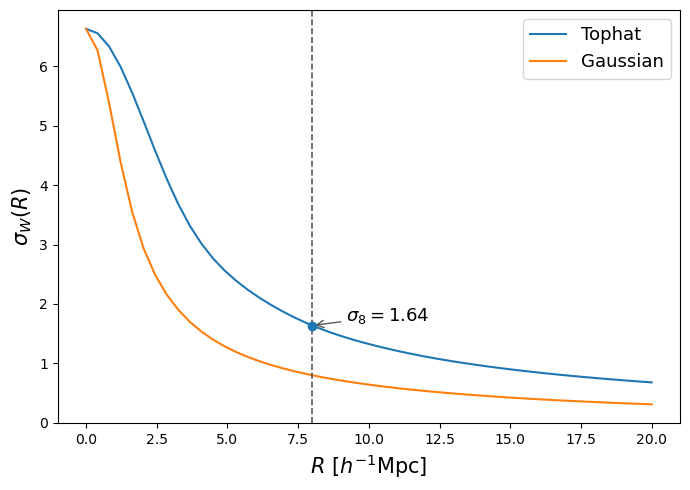

In [9]:
def compute_sigma_w(delta_field, window_type, radius, *, threads=8):
    window = WindowFunc(
        {'type': window_type, 'len_args': {'R': float(radius)}},
        delta_field.convols_info,
        threads=threads,
    )
    delta_w = delta_field @ window
    return np.sqrt((delta_w * delta_w).as_array().mean())


radii = np.linspace(0.0, 20.0, 50)
sigma_tophat = [compute_sigma_w(delta, 'sphere', radius) for radius in radii]
sigma_gauss = [compute_sigma_w(delta, 'gaussian', radius) for radius in radii]
sigma8 = compute_sigma_w(delta, 'sphere', 8.0)

plt.figure(figsize=(7, 5))
plt.plot(radii, sigma_tophat, label='Tophat')
plt.plot(radii, sigma_gauss, label='Gaussian')
plt.axvline(8.0, color='0.35', linestyle='--', linewidth=1.2)
plt.scatter([8.0], [sigma8], color='tab:blue', zorder=5)
plt.annotate(
    rf'$\sigma_8={sigma8:.3g}$',
    xy=(8.0, sigma8),
    xytext=(9.2, sigma8 * 1.05),
    arrowprops=dict(arrowstyle='->', color='0.35', lw=1.0),
    fontsize=13,
)
plt.xlabel(r'$R\ [h^{-1}{\rm Mpc}]$', fontsize=15)
plt.ylabel(r'$\sigma_W(R)$', fontsize=15)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig(figs_dir / 'counting_sigma_lowpass.png', dpi=200, bbox_inches='tight')
plt.show()


### High-pass response

The same RMS definition can also be applied to high-pass or band-pass windows. Here we compare CWS, the three-dimensional spherical cosine wavelet, with GDW, the Gaussian-derivative wavelet. Both windows have vanishing response to the constant background, so the measured $\sigma_W(R)$ reflects the scale-dependent fluctuation amplitude selected by the window rather than the large-scale mean density. Because CWS and GDW use different response shapes and normalizations, this figure is best read as a comparison of how the two high-pass kernels weight structure as their characteristic scale $R$ changes.


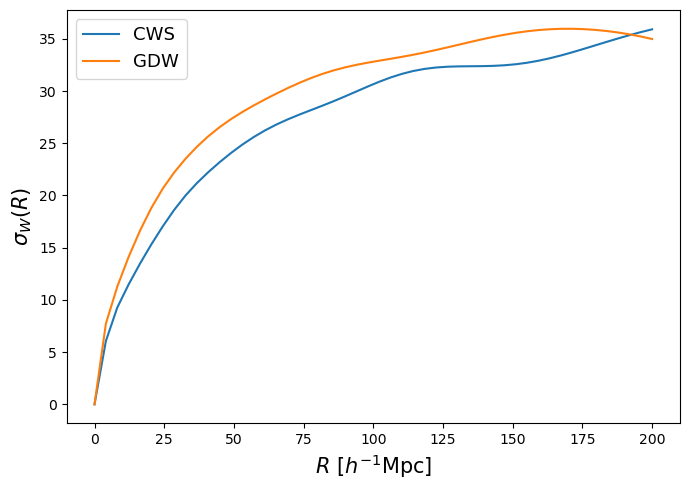

In [10]:
radii_hp = np.linspace(0.0, 200.0, 50)
sigma_cws = [compute_sigma_w(delta, 'cws', radius) for radius in radii_hp]
sigma_gdw = [compute_sigma_w(delta, 'gdw', radius) for radius in radii_hp]

plt.figure(figsize=(7, 5))
plt.plot(radii_hp, sigma_cws, label='CWS')
plt.plot(radii_hp, sigma_gdw, label='GDW')
plt.xlabel(r'$R\ [h^{-1}{\rm Mpc}]$', fontsize=15)
plt.ylabel(r'$\sigma_W(R)$', fontsize=15)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig(figs_dir / 'counting_sigma_highpass.png', dpi=200, bbox_inches='tight')
plt.show()
